In [4]:
import pandas as pd
import numpy as np
import itertools
from scipy.stats import ttest_1samp
import networkx as nx
import matplotlib.pyplot as plt
import pyreadr

In [5]:
# Load the rds file
result = pyreadr.read_r('06_Cb_BTM_table.rds')

# pyreadr returns a dictionary; the data is usually under the 'None' key 
# because rds files contain a single object without a specific name.
df = result[None]

print("-"*50+"Columns name"+50*"-")
print(df.columns)
print("-"*50+"Columns name"+50*"-")
print()


--------------------------------------------------Columns name--------------------------------------------------
Index(['segment_id', 'gene', 'karyotype', 'sample_id', 'NV', 'DP',
       'mutatation_status', 'mult_estimate', 'mutation_call', 'timed',
       'segment_name', 'sample', 'n_mutations', 'clock_mean', 'clock_low',
       'clock_high', 'clock_rank', 'class', 'is_WGD', 'ploidy', 'purity',
       'best_K', 'ttype'],
      dtype='object')
--------------------------------------------------Columns name--------------------------------------------------



# 1. Preprocessing e Filtraggio dei Dati

- Seleziona la coorte: 
usare colonna ttype per scegliere un tipo di tumore

- Filtraggio: filtrare le righe mantenendo solo i geni driver nella colonna gene o i segmenti chiave nella colonna segment_name.  

- Cleaning of the temporal data: 
check di timed e clock_mean (not null)

In [6]:
# Define the tumor type to analyze
TUMOR_TYPE = 'ESAD' 

# Select the cohort: filter rows for the chosen tumor type
df_1 = df[df['ttype'] == TUMOR_TYPE].copy()

# Clean temporal data: remove rows where 'clock_mean', 'clock_rank', or 'gene' are missing
df_1 = df_1.dropna(subset=['clock_mean', 'clock_rank', 'gene'])

# --- FIND DRIVER GENES DYNAMICALLY ---
# Since we don't know the drivers, we select the top N most frequent genes in this tumor
TOP_N_GENES = 15
top_frequent_genes = df_1['gene'].value_counts().head(TOP_N_GENES).index.tolist()
print(f"Using the top {TOP_N_GENES} most frequent genes as drivers:\n{top_frequent_genes}")

# Filter the dataset keeping only these top genes
df_1 = df_1[df_1['gene'].isin(top_frequent_genes)]

Using the top 15 most frequent genes as drivers:
['PTPRD', 'GRIN2A', 'STAG1', 'PIK3CA', 'WWTR1', 'TBL1XR1', 'KLHL6', 'COL6A6', 'EIF4A2', 'ETV5', 'FGD5', 'GATA2', 'GMPS', 'ARNT', 'MB21D2']


# 2. Creazione delle Coppie Co-occorrenti

- Raggruppa per paziente: usare  sample_id per isolare i dati di ogni singolo individuo.  


- Genera le combinazioni: Per ogni paziente, identificare tutte le combinazioni possibili di coppie di eventi che co-occorrono  (evento A e evento B)

- Creazione data frame: ogni riga rappresenta una coppia (A, B) per uno specifico sample_id, associando a ciascun evento il proprio clock_mean e clock_rank (o best_K).

# 3. Score
Score (il loro) per detemrinare l'ordine temporale di ogni coppia dentro lo stesso paziente 
  

- 0: se il clock_rank Evento A=clock_rank Evento B, oppure se i loro pseudotempi sono identici (cioè gli eventi sono co-occorrenti)


- -1: clock_mean Evento A< clock_mean Evento B,  A precede B.  


- +1: il clock_mean Evento A > clock_mean Evento B, A segue B.

In [7]:
pairs_list = []

# Group data by patient (sample_id)
for sample_id, group in df_1.groupby('sample_id'):
    
    # Isolate unique events per individual (remove duplicates of the same gene)
    group_unique = group.drop_duplicates(subset=['gene'])
    
    # Skip patients with fewer than 2 mutations (cannot form a pair)
    if len(group_unique) < 2:
        continue 
        
    # Generate all possible combinations of co-occurring events (Gene A, Gene B)
    for (i, row_A), (j, row_B) in itertools.combinations(group_unique.iterrows(), 2):
        gene_A = row_A['gene']
        gene_B = row_B['gene']
        
        # Sort alphabetically so pair (X, Y) is treated the same as (Y, X)
        if gene_A > gene_B:
            gene_A, gene_B = gene_B, gene_A
            row_A, row_B = row_B, row_A
            
        
        # Determine temporal order within the same patient
        
        # Score 0: Same rank or exact same pseudo-time (co-occurring)
        if row_A['clock_rank'] == row_B['clock_rank'] or row_A['clock_mean'] == row_B['clock_mean']:
            score = 0   
        # Score -1: A precedes B
        elif row_A['clock_mean'] < row_B['clock_mean']:
            score = -1  
        # Score +1: A follows B
        else:
            score = 1   
            
        # Create dictionary row for the dataframe
        pairs_list.append({
            'gene_A': gene_A,
            'gene_B': gene_B,
            'score': score
        })

# Create the pairs DataFrame
df_pairs = pd.DataFrame(pairs_list)

# Fase 4: Aggregazione e Test Statistico

- Raggruppa per Coppia: isolare le singole coppie di eventi (A, B) ignorando il sample_id, per ottenere l'elenco completo degli score assegnati a quella specifica combinazione in tutta la coorte

- Calcola la Media: media aritmetica degli score per la coppia. valore negativo= primo evento tende a verificarsi frequentemente prima del secondo
 
- T-test contro il vlaore 0  ai punteggi per verificarne la significatività.  mantenere solo risultati con  relazioni temporali con un p-value $\le 0.05$.  

In [15]:
results = []

# Group by specific Gene Pair (ignoring sample_id)
for (gene_A, gene_B), group in df_pairs.groupby(['gene_A', 'gene_B']):
    
    scores = group['score'].values
    n_patients = len(scores)
    
    # Optional: only analyze pairs that appear in at least 5 patients to ensure statistical validity
    if n_patients < 5:
        continue
        
    # Calculate the arithmetic mean of the scores
    mean_score = scores.mean()
    
    # T-test against the value 0
    if np.all(scores == 0):
        # If all scores are 0, variance is zero, making p-value insignificant
        p_val = 1.0 
    else:
        t_stat, p_val = ttest_1samp(scores, 0)
        
    results.append({
        'gene_A': gene_A,
        'gene_B': gene_B,
        'mean_score': mean_score,
        'p_value': p_val
    })

df_results = pd.DataFrame(results)

# Keep only significant temporal relationships with a p-value <= 0.05
df_significant = df_results[df_results['p_value'] <= 0.1].copy()
print(f"Found {len(df_significant)} significant trajectories.")

Found 3 significant trajectories.


# 5. Costruzione grafo  
crea grafo con  NetworkX 

Nodi: geni driver o alterazioni cromosomiche selezionate

Archi: iterando sulle coppie significative secondo il t-test:
- media score negativa: arco da evento A ad evento B
- media score negativa: arco da evento B ad evento A


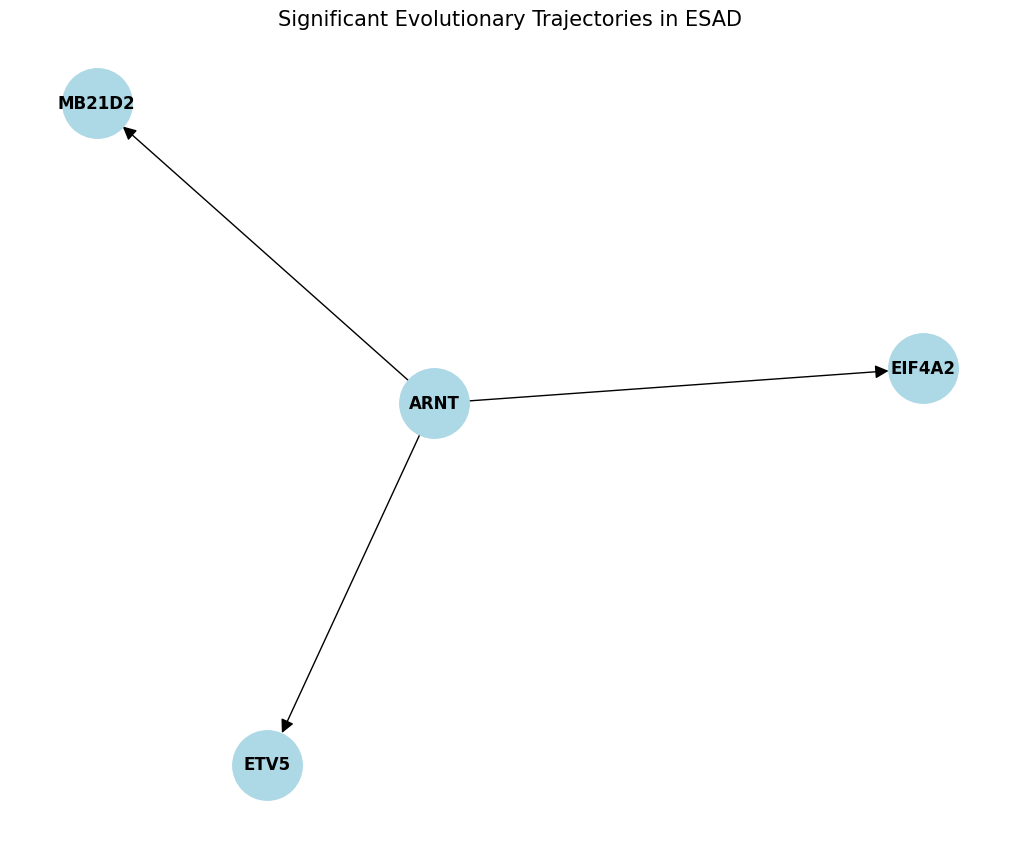

In [16]:
# Create directed graph with NetworkX
G = nx.DiGraph()

# Iterate over significant pairs to draw edges
for index, row in df_significant.iterrows():
    g_A = row['gene_A']
    g_B = row['gene_B']
    mean = row['mean_score']
    
    # NetworkX automatically adds nodes when you add edges
    if mean < 0:
        # Negative mean: A precedes B -> arrow from A to B
        G.add_edge(g_A, g_B, weight=abs(mean))
    elif mean > 0:
        # Positive mean: B precedes A -> arrow from B to A
        G.add_edge(g_B, g_A, weight=abs(mean))


# Setup and draw the graph
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(G, seed=42) # Layout for node positioning

nx.draw(G, pos, with_labels=True, node_color='lightblue', node_size=2500, 
        font_size=12, font_weight='bold', arrows=True, arrowsize=20)

plt.title(f"Significant Evolutionary Trajectories in {TUMOR_TYPE}", size=15)
plt.show()

In [17]:
print(f"1. Righe dopo il filtro del tumore: {len(df_1)}")
print(f"2. Numero totale di coppie create: {len(df_pairs)}")
print(f"3. Coppie analizzate statisticamente: {len(df_results)}")
print(f"4. Traiettorie SIGNIFICATIVE (p <= 0.05): {len(df_significant)}")

1. Righe dopo il filtro del tumore: 461
2. Numero totale di coppie create: 1485
3. Coppie analizzate statisticamente: 105
4. Traiettorie SIGNIFICATIVE (p <= 0.05): 3
